# Ensemble strategy vs SPY — 2026 backtest

Loads the saved production blend (XGB two-stage x CatGNN, `experiments/production/`),
forms daily calls on the 2026 test period (top 3% conviction per day: long the
bullish calls, short the bearish), holds each cohort 10 trading days
(overlapping, 1/10 of the book turns over daily), charges 20 bps round trip
per position, and plots the cumulative equity curve against SPY buy-and-hold.
Saves the figure to `notebooks/ensemble_vs_spy.png`.

Note what's being compared: the strategy is a **dollar-neutral long-short**
book (market exposure ~0), SPY is a long-only market position — so this is
"alpha engine vs the market", not two versions of the same risk.

In [1]:
import sys, pathlib, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

root = pathlib.Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path[:0] = [str(root), str(root / 'experiments')]
from exp_harness import load_sweep_dataset, load_universe, EXP
import nn_common as nc

PROD = EXP / 'production'
HORIZON, K, COST_RT = 10, 0.03, 0.002
config = json.loads((PROD / 'config.json').read_text())
features, w = config['features'], config['w_xgb']
print('model trained:', config['trained'], '| blend w_xgb =', w,
      '| features:', len(features))

model trained: 2026-07-20T11:33:49 | blend w_xgb = 0.2 | features: 81


In [2]:
# score the 2026 test rows with the saved production blend
d, _, fit_m, val_m, te_m, _ = load_sweep_dataset(horizon=HORIZON, window_years=1)
dates_all = d.index.get_level_values('date')

import xgboost as xgb
import torch
b1, b2 = xgb.Booster(), xgb.Booster()
b1.load_model(str(PROD / 'stage1.ubj'))
b2.load_model(str(PROD / 'stage2.ubj'))
dm = xgb.DMatrix(d.loc[te_m, features], feature_names=features)
s_xgb = b1.predict(dm) * (2.0 * b2.predict(dm) - 1.0)

scaler = pd.read_parquet(PROD / 'scaler.parquet')
_, cat = load_universe()
cat_map = {c: i for i, c in enumerate(config['categories'])}
cat_codes = np.array([cat_map.get(c, len(cat_map)) for c in
                      d.index.get_level_values('ticker').map(cat)])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gnn = nc.CatGNN(len(features), config['gnn_hidden']).to(device)
gnn.load_state_dict(torch.load(PROD / 'catgnn.pt', map_location=device,
                               weights_only=True))
gnn.eval()
Xn = nc.standardize(d[features], scaler['median'], scaler['mean'], scaler['std'])
days_te = nc.day_slices(te_m, dates_all, cat_codes)
s_gnn = nc.day_scores(gnn, days_te, Xn, device)

te = pd.DataFrame({'s_xgb': s_xgb, 's_gnn': s_gnn}, index=d.index[te_m])
g = te.groupby(level='date')
z = lambda col: (te[col] - g[col].transform('mean')) / g[col].transform('std').replace(0, 1)
te['score'] = w * z('s_xgb') + (1 - w) * z('s_gnn')
print('scored rows:', len(te), '| days:', te.index.get_level_values(0).nunique())

scored rows: 178560 | days: 120


In [3]:
# daily calls: top-K conviction, direction by score vs daily median
gd = te.groupby(level='date')['score']
te['med'] = gd.transform('median')
te['conv'] = (te['score'] - te['med']).abs()
picks = (te.groupby(level='date', group_keys=False)
         .apply(lambda x: x.nlargest(max(int(len(x) * K), 1), 'conv')))
picks['sign'] = np.where(picks['score'] >= picks['med'], 1.0, -1.0)
print('calls:', len(picks), '| avg per day:',
      round(picks.groupby(level='date').size().mean(), 1),
      '| long share:', round((picks['sign'] > 0).mean(), 3))

calls: 5280 | avg per day: 44.0 | long share: 0.368


In [4]:
# overlapping 10-day long-short book, 20 bps round trip charged at entry
fields, _cat = load_universe()
close = fields['Close']
r1 = close.pct_change(fill_method=None)
didx = close.index

contrib = pd.Series(0.0, index=didx)
for t, grp in picks.groupby(level='date'):
    pos = didx.get_loc(t)
    tk = grp.index.get_level_values('ticker')
    sg = grp['sign'].to_numpy()
    for h in range(1, HORIZON + 1):
        if pos + h >= len(didx):
            break
        day = didx[pos + h]
        contrib[day] += np.nanmean(sg * r1.loc[day, tk].to_numpy())
    if pos + 1 < len(didx):
        contrib[didx[pos + 1]] -= COST_RT

strat = (contrib / HORIZON).loc['2026-01-02':didx.max()]
spy = r1['SPY'].reindex(strat.index).fillna(0.0)

def stats(r, name):
    cum = (1 + r).cumprod()
    ann = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    dd = (cum / cum.cummax() - 1).min()
    return {'': name, 'total_ret': f'{cum.iloc[-1] - 1:+.1%}',
            'ann_ret': f'{ann:+.1%}', 'ann_vol': f'{vol:.1%}',
            'sharpe': round(ann / vol, 2), 'max_dd': f'{dd:.1%}'}

tbl = pd.DataFrame([stats(strat, 'ensemble L/S (net)'), stats(spy, 'SPY')])
print(tbl.to_string(index=False))

                   total_ret ann_ret ann_vol  sharpe max_dd
ensemble L/S (net)    +11.7%  +22.6%   15.3%    1.48  -5.1%
               SPY    +11.3%  +21.7%   14.0%    1.56  -8.9%


saved -> C:\Users\user\Desktop\CS\overp\outperforming\notebooks\ensemble_vs_spy.png


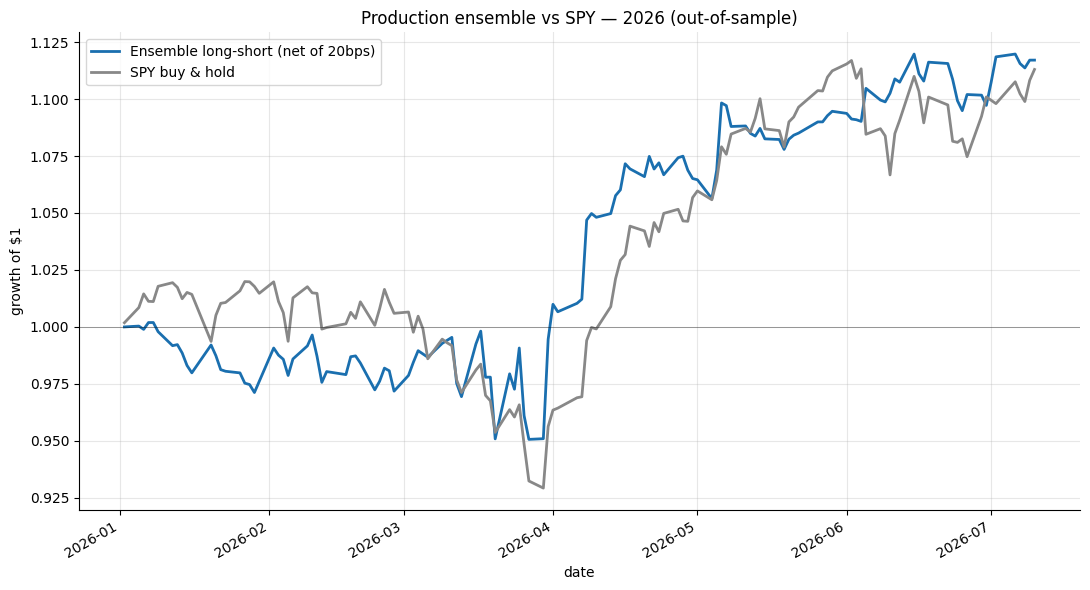

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
(1 + strat).cumprod().plot(ax=ax, lw=2, color='#1a6faf',
                           label='Ensemble long-short (net of 20bps)')
(1 + spy).cumprod().plot(ax=ax, lw=2, color='#888888', label='SPY buy & hold')
ax.axhline(1.0, color='k', lw=0.5, alpha=0.5)
ax.set_title('Production ensemble vs SPY — 2026 (out-of-sample)')
ax.set_ylabel('growth of $1')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
out = root / 'notebooks' / 'ensemble_vs_spy.png'
fig.savefig(out, dpi=150)
print('saved ->', out)

In [6]:
# like-for-like vs the old model: LONG-ONLY top 25% by blend score,
# same 10d overlapping holds, same 20bps costs; plus equal-weight universe
top_q = 0.25
picks_lo = (te.groupby(level='date', group_keys=False)
            .apply(lambda x: x.nlargest(max(int(len(x) * top_q), 1), 'score')))
contrib_lo = pd.Series(0.0, index=didx)
for t, grp in picks_lo.groupby(level='date'):
    pos = didx.get_loc(t)
    tk = grp.index.get_level_values('ticker')
    for h in range(1, HORIZON + 1):
        if pos + h >= len(didx):
            break
        day = didx[pos + h]
        contrib_lo[day] += np.nanmean(r1.loc[day, tk].to_numpy())
    if pos + 1 < len(didx):
        contrib_lo[didx[pos + 1]] -= COST_RT
strat_lo = (contrib_lo / HORIZON).loc[strat.index]
ew = r1.mean(axis=1).reindex(strat.index).fillna(0.0)

tbl2 = pd.DataFrame([stats(strat_lo, 'long-only top 25% (net)'),
                     stats(ew, 'equal-weight universe'),
                     stats(spy, 'SPY'),
                     stats(strat, 'ensemble L/S (net)')])
print(tbl2.to_string(index=False))
alpha = (1 + strat_lo).prod() - (1 + ew).prod()
print('long-only top25 alpha over equal-weight universe: ' + format(alpha, '+.1%'))


                        total_ret ann_ret ann_vol  sharpe max_dd
long-only top 25% (net)    +10.8%  +21.1%   15.5%    1.36  -8.5%
  equal-weight universe    +10.5%  +20.0%   10.9%    1.82  -6.5%
                    SPY    +11.3%  +21.7%   14.0%    1.56  -8.9%
     ensemble L/S (net)    +11.7%  +22.6%   15.3%    1.48  -5.1%
long-only top25 alpha over equal-weight universe: +0.3%


saved -> C:\Users\user\Desktop\CS\overp\outperforming\notebooks\ensemble_vs_benchmarks.png


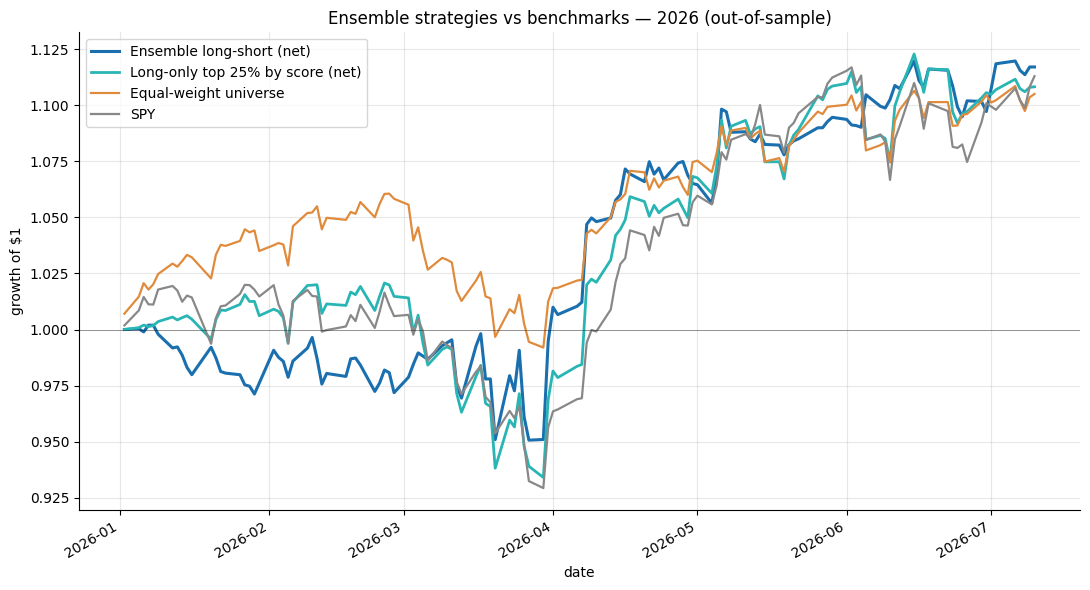

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
(1 + strat).cumprod().plot(ax=ax, lw=2.2, color='#1a6faf',
                           label='Ensemble long-short (net)')
(1 + strat_lo).cumprod().plot(ax=ax, lw=2, color='#2ab5b5',
                              label='Long-only top 25% by score (net)')
(1 + ew).cumprod().plot(ax=ax, lw=1.6, color='#e08a3c',
                        label='Equal-weight universe')
(1 + spy).cumprod().plot(ax=ax, lw=1.6, color='#888888', label='SPY')
ax.axhline(1.0, color='k', lw=0.5, alpha=0.5)
ax.set_title('Ensemble strategies vs benchmarks — 2026 (out-of-sample)')
ax.set_ylabel('growth of $1')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
out2 = root / 'notebooks' / 'ensemble_vs_benchmarks.png'
fig.savefig(out2, dpi=150)
print('saved ->', out2)
